In [1]:
!pip install the_well

  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.7.0
    Uninstalling fsspec-2025.7.0:
      Successfully uninstalled fsspec-2025.7.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [the_well]2/3 [the_well]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
s3fs 2025.7.0 requires fsspec==2025.7.0, but you have fsspec 2024.10.0 which is incompatible.


In [7]:
BASE_PATH = './datasets'
DATASET = 'turbulent_radiative_layer_2D'
SPLIT = 'train'

In [2]:
from the_well.data import WellDataset
from the_well.utils.download import well_download
import matplotlib.pyplot as plt

In [8]:
# Takes a long time, modify your script so you only run this once.
well_download(base_path=BASE_PATH, dataset=DATASET, split=SPLIT)

** Resuming transfer from byte position 576
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0    663      0 --:--:-- --:--:-- --:--:--   681
** Resuming transfer from byte position 635467072
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100   197  100   197    0     0    653      0 --:--:-- --:--:-- --:--:--   667
** Resuming transfer from byte position 635467072
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0   5338      0 --:--:-- --:--:-- --:--:--  5472
** Resuming transfer from byte position 635467072
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0   6725      0 --:--:-- --:--:-- --:--:--  6793
** Resuming transfer from byte position 635467072
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0   6700      0 --:--:-- --:--:-- --:--:--  6793
** Resuming transfer from byte position 635467072
  % Total 

In [9]:
dataset = WellDataset(
    well_base_path='./datasets/' + BASE_PATH,
    well_dataset_name=DATASET,
    well_split_name=SPLIT,
)
print(type(dataset))

<class 'the_well.data.datasets.WellDataset'>


In [10]:
len(dataset)

7200

In [11]:
dataset[0].keys()

dict_keys(['input_fields', 'output_fields', 'constant_scalars', 'boundary_conditions', 'space_grid', 'input_time_grid', 'output_time_grid'])

# Visualization of the data

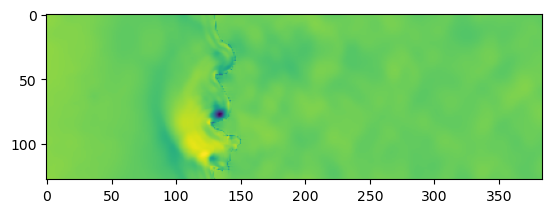

In [ ]:
idx = 23
channel_id = 1
plt.imshow(dataset[idx]['input_fields'][0][:,:,channel_id])

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from ipywidgets import interact, IntSlider

def visualize_dataset(idx):
    # Retrieve the data for the selected index
    # Assuming 'input_fields' shape is (frames, height, width, channels)
    data = dataset[idx]['input_fields'][0]

    fig, ax = plt.subplots()
    im = ax.imshow(data[:, :, 0])
    ax.set_title(f"Dataset Index: {idx} | Channel: 0")

    def update(channel_id):
        # Update image data for each frame of the animation
        im.set_data(data[:, :, channel_id])
        ax.set_title(f"Dataset Index: {idx} | Channel: {channel_id}")
        return [im]

    # Create animation: frames = number of channels/time steps
    num_channels = data.shape[-1]
    ani = FuncAnimation(fig, update, frames=range(num_channels),
                        interval=200, blit=True)

    plt.show()

# Create the interactive slider
interact(visualize_dataset, idx=IntSlider(min=0, max=len(dataset)-1, step=1, value=0));

interactive(children=(IntSlider(value=0, description='idx', max=7199), Output()), _dom_classes=('widget-intera…